In [83]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


df = pd.read_csv('../data/penjualan_tiket_pesawat (1).csv') 

df.head() #MEMANGGIL DATA SET LEWAT PANDAS



,Transaction_ID,City,Gender,Date,Ticket_Quantity,Ticket_Price,Airline,Payment_Method,Total
0,1,Medan,Female,2024-03-25,5,1340246.0,Garuda,E-Wallet,6701230.0
1,2,Surabaya,Female,2024-02-15,4,1935645.0,Garuda,Transfer Bank,7742580.0
2,3,Medan,Female,2024-01-24,4,949000.0,Citilink,Transfer Bank,3796000.0
3,4,Medan,Female,2024-01-05,5,1506013.0,Lion Air,E-Wallet,7530065.0
4,5,Jakarta,Male,2024-01-30,3,842715.0,Lion Air,E-Wallet,2528145.0


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Transaction_ID   500 non-null    int64  
 1   City             500 non-null    object 
 2   Gender           500 non-null    object 
 3   Date             500 non-null    object 
 4   Ticket_Quantity  500 non-null    int64  
 5   Ticket_Price     500 non-null    float64
 6   Airline          500 non-null    object 
 7   Payment_Method   500 non-null    object 
 8   Total            500 non-null    float64
dtypes: float64(2), int64(2), object(5)
memory usage: 35.3+ KB


In [85]:
df.describe()

,Transaction_ID,Ticket_Quantity,Ticket_Price,Total
count,500.000000,500.000000,5.000000e+02,5.000000e+02
mean,250.500000,3.032000,1.251348e+06,3.793494e+06
std,144.481833,1.383765,4.433147e+05,2.265379e+06
min,1.000000,1.000000,5.092100e+05,5.280000e+05
25%,125.750000,2.000000,8.493028e+05,1.889234e+06
50%,250.500000,3.000000,1.233666e+06,3.485085e+06
75%,375.250000,4.000000,1.649518e+06,5.244934e+06
max,500.000000,5.000000,1.997273e+06,9.972850e+06


In [86]:
df["Airline"].unique()

array(['Garuda', 'Citilink', 'Lion Air'], dtype=object)

In [87]:
df["Airline"].value_counts()

Airline
Garuda      184
Lion Air    162
Citilink    154
Name: count, dtype: int64

In [88]:
# Kolom fitur (independen)
X = df[['Ticket_Price', 'Total']]

# Kolom target (label)
y = df[['City', 'Gender', 'Date', 'Airline', 'Payment_Method']]


In [89]:
X.head()

,Ticket_Price,Total
0,1340246.0,6701230.0
1,1935645.0,7742580.0
2,949000.0,3796000.0
3,1506013.0,7530065.0
4,842715.0,2528145.0


In [90]:
y.head()

,City,Gender,Date,Airline,Payment_Method
0,Medan,Female,2024-03-25,Garuda,E-Wallet
1,Surabaya,Female,2024-02-15,Garuda,Transfer Bank
2,Medan,Female,2024-01-24,Citilink,Transfer Bank
3,Medan,Female,2024-01-05,Lion Air,E-Wallet
4,Jakarta,Male,2024-01-30,Lion Air,E-Wallet


In [91]:
y = df['Ticket_Price']


In [92]:
y = df['Total']


In [93]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = SVC(kernel='linear')
model.fit(X_train, y_train)


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [109]:
y_pred = model.predict(X_test)

# Akurasi
print(f"Akurasi: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# Laporan klasifikasi
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred))


Akurasi: 0.00%

Laporan Klasifikasi:
               precision    recall  f1-score   support

    662066.0       0.00      0.00      0.00       1.0
    684026.0       0.00      0.00      0.00       0.0
    686391.0       0.00      0.00      0.00       1.0
    687857.0       0.00      0.00      0.00       0.0
    738270.0       0.00      0.00      0.00       1.0
    748070.0       0.00      0.00      0.00       1.0
    749766.0       0.00      0.00      0.00       0.0
    816316.0       0.00      0.00      0.00       0.0
    823859.0       0.00      0.00      0.00       1.0
    969551.0       0.00      0.00      0.00       1.0
    970551.0       0.00      0.00      0.00       0.0
   1004251.0       0.00      0.00      0.00       1.0
   1004322.0       0.00      0.00      0.00       0.0
   1022068.0       0.00      0.00      0.00       1.0
   1026744.0       0.00      0.00      0.00       0.0
   1108960.0       0.00      0.00      0.00       0.0
   1118854.0       0.00      0.00      0.00

C:\Users\MyLaptop\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
C:\Users\MyLaptop\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
C:\Users\MyLaptop\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
C:\Users\MyLaptop\

In [103]:
y_pred = model.predict(X_test)

In [97]:
import seaborn

C:\Users\MyLaptop\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
C:\Users\MyLaptop\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
C:\Users\MyLaptop\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
C:\Users\MyLaptop\


Confusion Matrix:
 [[0 1 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 0 0]]


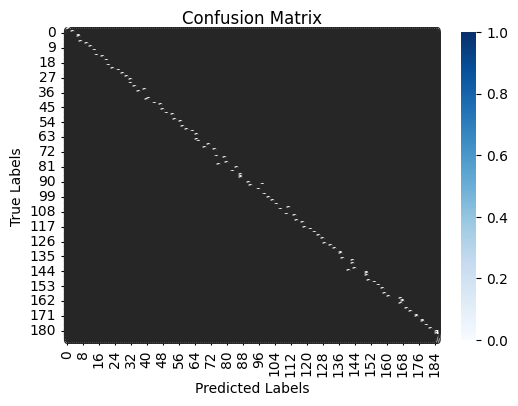

In [104]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Buat confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Jika kamu tahu nama kelas (opsional, agar lebih informatif)
# misalnya: class_names = ['Negatif', 'Positif']
# maka tambahkan ke heatmap di bagian "xticklabels" dan "yticklabels"

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()